In [2]:
!pip install datasets osmnx networkx geopandas folium scikit-learn matplotlib

In [ ]:
""Ghost Grid: Detecting Hidden Energy Flows in Smart Buildings

Objective
Smart buildings consume energy through multiple systems such as HVAC, lighting, and miscellaneous electrical loads.  
However, abnormal or hidden energy usage patterns often go unnoticed.

This project aims to:
- Analyze building energy consumption data
- Identify unusual or inefficient energy usage patterns
- Detect hidden "ghost loads" using machine learning anomaly detection

The project uses the EnergyBench dataset and applies Isolation Forest to identify unusual energy behavior.

In [ ]:
"" Step 1: Import Required Libraries

We import the libraries needed for:
- Data handling (pandas, numpy)
- Visualization (matplotlib, seaborn)
- Machine learning anomaly detection (Isolation Forest)

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Spatial and mapping
import osmnx as ox
import geopandas as gpd
import folium

# ML / Anomaly detection
from sklearn.ensemble import IsolationForest

# Hugging Face datasets
from datasets import load_dataset

In [ ]:
"" Step 2: Load EnergyBench Dataset

The EnergyBench dataset contains energy usage data for different building systems.

Since the full dataset is large, we stream the dataset and collect a subset of records for analysis. This prevents long download times and reduces memory usage.

In [ ]:
from huggingface_hub import login
login(token="")

In [4]:
from datasets import load_dataset
import pandas as pd

# Stream dataset instead of downloading full dataset
dataset = load_dataset("ai-iot/EnergyBench", split="train", streaming=True)

# Take only first 5000 records
sample = []
for i, row in enumerate(dataset):
    sample.append(row)
    if i >= 5000:
        break

df_energy = pd.DataFrame(sample)

df_energy.head()

Resolving data files:   0%|          | 0/1945 [00:00<?, ?it/s]

,mels_S,lig_S,mels_N,hvac_N,hvac_S,Timestamp
0,1.2,0.2,7.5,37.400002,19.500000,2018-01-01 01:00:00
1,1.3,0.2,6.8,37.500000,19.889999,2018-01-01 01:15:00
2,1.1,0.2,7.4,38.000000,19.299999,2018-01-01 01:30:00
3,1.2,0.2,7.7,37.200001,18.889999,2018-01-01 01:45:00
4,1.1,0.2,7.3,37.400002,24.700001,2018-01-01 02:00:00


In [ ]:
"" Step 3: Dataset Overview

The dataset contains energy consumption measurements for different building systems:

- mels_S : Miscellaneous Electric Loads (South zone)
- lig_S : Lighting consumption (South zone)
- mels_N : Miscellaneous Electric Loads (North zone)
- hvac_N : HVAC energy usage (North zone)
- hvac_S : HVAC energy usage (South zone)
- Timestamp : Time of measurement

These features allow us to analyze how different building systems consume electricity over time.

In [13]:
df_energy.info()

<class 'pandas.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   mels_S        5001 non-null   float64       
 1   lig_S         5001 non-null   float64       
 2   mels_N        5001 non-null   float64       
 3   hvac_N        5001 non-null   float64       
 4   hvac_S        5001 non-null   float64       
 5   Timestamp     5001 non-null   datetime64[us]
 6   total_energy  5001 non-null   float64       
 7   hour          5001 non-null   int32         
 8   day           5001 non-null   int32         
 9   anomaly       5001 non-null   int64         
dtypes: datetime64[us](1), float64(6), int32(2), int64(1)
memory usage: 351.8 KB


In [14]:
df_energy.describe()

,mels_S,lig_S,mels_N,hvac_N,hvac_S,Timestamp,total_energy,hour,day,anomaly
count,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001,5001.000000,5001.000000,5001.000000,5001.000000
mean,2.929624,1.601326,10.053824,42.466454,22.582028,2018-01-27 02:00:00,79.633257,11.482304,14.011998,0.900020
min,0.000000,0.000000,1.700000,0.000000,0.000000,2018-01-01 01:00:00,10.770000,0.000000,1.000000,-1.000000
25%,1.600000,0.200000,7.420000,36.600000,18.600000,2018-01-14 01:30:00,65.800000,5.000000,7.000000,1.000000
50%,2.100000,0.400000,8.572727,39.400000,20.390000,2018-01-27 02:00:00,74.280000,11.000000,14.000000,1.000000
75%,3.796428,3.446429,12.200000,46.200000,24.300000,2018-02-09 02:30:00,92.300000,17.000000,20.000000,1.000000
max,11.100000,6.900000,32.700001,79.300000,68.090000,2018-02-22 03:00:00,165.299999,23.000000,31.000000,1.000000
std,2.059176,1.746590,4.870038,10.960007,10.232318,NaN,21.048809,6.929252,8.272887,0.435892


In [5]:
df_energy.columns

Index(['mels_S', 'lig_S', 'mels_N', 'hvac_N', 'hvac_S', 'Timestamp'], dtype='str')

In [ ]:
""Step 4 — Create Total Energy Consumption Feature

To analyze overall energy behavior, we combine the individual energy components into a single variable called total_energy.

This represents the total energy consumed at each timestamp.

In [6]:
# Combine energy sources into total energy consumption
df_energy["total_energy"] = (
    df_energy["mels_S"] +
    df_energy["mels_N"] +
    df_energy["hvac_S"] +
    df_energy["hvac_N"] +
    df_energy["lig_S"]
)

# View updated dataframe
df_energy.head()

,mels_S,lig_S,mels_N,hvac_N,hvac_S,Timestamp,total_energy
0,1.2,0.2,7.5,37.400002,19.500000,2018-01-01 01:00:00,65.800002
1,1.3,0.2,6.8,37.500000,19.889999,2018-01-01 01:15:00,65.690000
2,1.1,0.2,7.4,38.000000,19.299999,2018-01-01 01:30:00,65.999999
3,1.2,0.2,7.7,37.200001,18.889999,2018-01-01 01:45:00,65.190000
4,1.1,0.2,7.3,37.400002,24.700001,2018-01-01 02:00:00,70.700003


In [ ]:
"" Step 5: Convert Timestamp to Datetime

Time information is converted into datetime format so that we can perform time-based analysis and visualizations.

In [7]:
# Convert timestamp column to datetime
df_energy["Timestamp"] = pd.to_datetime(df_energy["Timestamp"])

# Extract useful time features
df_energy["hour"] = df_energy["Timestamp"].dt.hour
df_energy["day"] = df_energy["Timestamp"].dt.day

In [8]:
# Select features used for anomaly detection
features = df_energy[
    [
        "mels_S",
        "mels_N",
        "hvac_S",
        "hvac_N",
        "lig_S",
        "total_energy"
    ]
]

In [ ]:
"" Step 6: Detect Hidden Energy Anomalies

Isolation Forest is an anomaly detection algorithm that identifies unusual observations in data.

In this project, it helps detect hidden energy spikes or abnormal system behavior that could indicate:
- energy inefficiency
- malfunctioning equipment
- ghost electrical loads

In [9]:
# Create Isolation Forest model
model = IsolationForest(
    contamination=0.05,   # assume ~5% anomalies
    random_state=42
)

# Train model and predict anomalies
df_energy["anomaly"] = model.fit_predict(features)

In [10]:
# Extract anomaly records
ghosts = df_energy[df_energy["anomaly"] == -1]

# Display some anomalies
ghosts.head()

,mels_S,lig_S,mels_N,hvac_N,hvac_S,Timestamp,total_energy,hour,day,anomaly
166,8.3,4.3,22.100000,56.400002,49.099998,2018-01-02 18:30:00,140.200001,18,2,-1
172,7.4,2.0,24.000000,37.400002,43.099998,2018-01-02 20:00:00,113.900000,20,2,-1
173,7.4,4.2,23.299999,46.200000,49.300000,2018-01-02 20:15:00,130.399999,20,2,-1
174,7.2,4.2,26.200001,37.290000,48.100000,2018-01-02 20:30:00,122.990000,20,2,-1
259,7.9,5.2,13.100000,37.900002,50.000000,2018-01-03 17:45:00,114.100002,17,3,-1


In [11]:
print("Ghost energy events detected:", len(ghosts))

Ghost energy events detected: 250


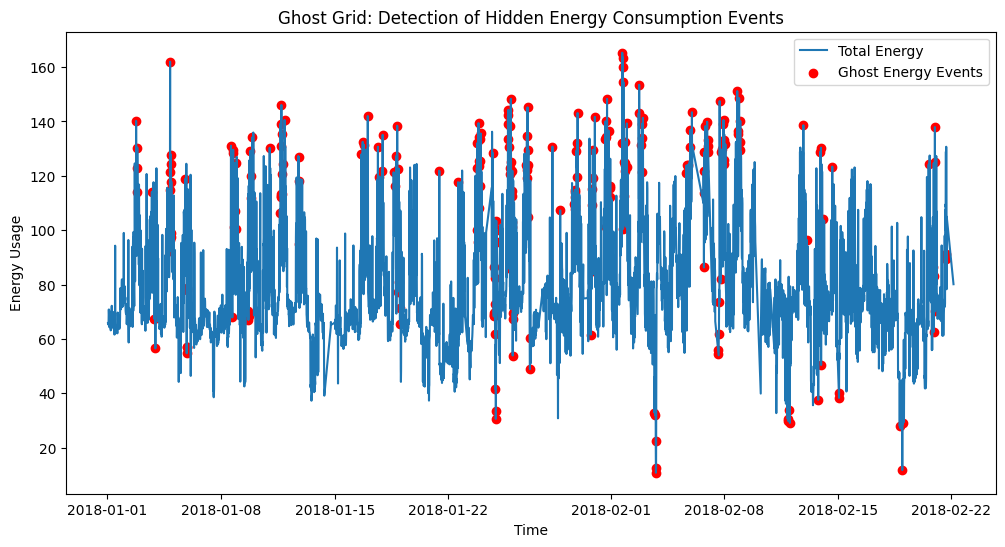

In [16]:
# Step 7: Visualize Hidden Energy Flows
# We plot total energy consumption over time and highlight anomalous events.
# Blue line → normal energy pattern
# Red dots → hidden or abnormal energy spikes

plt.figure(figsize=(12,6))

# Plot energy consumption
plt.plot(df_energy["Timestamp"], df_energy["total_energy"], label="Total Energy")

# Plot anomalies
plt.scatter(
    ghosts["Timestamp"],
    ghosts["total_energy"],
    color="red",
    label="Ghost Energy Events"
)

plt.legend()
plt.title("Ghost Grid: Detection of Hidden Energy Consumption Events")
plt.xlabel("Time")
plt.ylabel("Energy Usage")

plt.show()

In [18]:
!pip install shap tensorflow

In [ ]:
"" Step 8: Explainable AI for Energy Anomalies

To better understand why the anomaly detection model flagged certain energy patterns,
we apply SHAP (SHapley Additive Explanations).

SHAP helps identify which features contributed the most to abnormal energy behavior.
This improves transparency and allows building operators to diagnose inefficiencies.

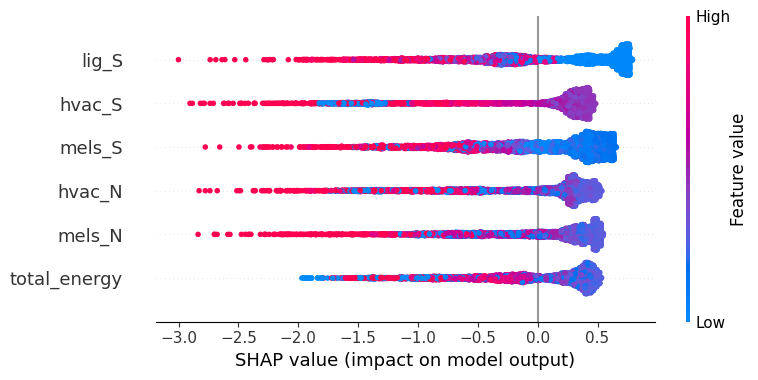

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 7.0 MB/s  0:00:00
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 2.4/332.0 MB 12.0 MB/s eta 0:00:28
    --------------------------------------- 4.7/332.0 MB 12.1 MB/s eta 0:00:28
    --------------------------------------- 7.6/332.0 MB 12.2 MB/s eta 0:00:27
   - -------------------------------------- 10.2/332.0 MB 12.1 MB/s eta 0:00:27
   - -------------------------------------- 12.6/332.0 MB 12.3 MB/s eta 0:00:27
   - -------------------------------------- 15.5/332.0 MB 12.3 MB/s eta 0:00:26
   -- ------------------------------------- 17.8/332.0 MB 12.3 MB/s eta 0:00:26
   -- ------------------------------------- 20.4/332.0 MB 12.3 MB/s eta 0:00:26
   -- ------------------------------------- 23.3/332.0 MB 12.3 MB/s eta 0:00:26
   --- ------------------------------------ 25.7/332.0 MB 12.4 M

In [19]:
import shap

# Train model again
model = IsolationForest(contamination=0.05, random_state=42)
model.fit(features)

# SHAP explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(features)

# Plot feature importance
shap.summary_plot(shap_values, features)

In [43]:
# SHAP Mean Values Interpretation
print("Mean SHAP values for anomalous events:\n")
for feature, value in mean_shap.items():
    print(f"{feature:10s} -> {value:.4f}")
    
print("\nInterpretation:")
print("HVAC_S contributes most to ghost loads.")
print("Total energy and miscellaneous electric loads (MELS) are also significant.")
print("Lighting contributes least.")

Mean SHAP values for anomalous events:

hvac_S     -> 1.0395
total_energy -> 0.9189
mels_S     -> 0.8361
mels_N     -> 0.8336
hvac_N     -> 0.6863
lig_S      -> 0.6199

Interpretation:
HVAC_S contributes most to ghost loads.
Total energy and miscellaneous electric loads (MELS) are also significant.
Lighting contributes least.


In [ ]:
"" Step 9: Estimating Carbon Emissions

Energy consumption directly contributes to carbon emissions depending on the energy source.
We estimate CO₂ emissions using a standard conversion factor for electricity.

This allows us to quantify the environmental impact of detected ghost energy loads.

In [20]:
# Approximate CO2 factor (kg CO2 per kWh)
co2_factor = 0.4

# Estimate total energy usage
df_energy["total_energy"] = features.sum(axis=1)

# Estimate emissions
df_energy["co2_emissions"] = df_energy["total_energy"] * co2_factor

df_energy.head()

,mels_S,lig_S,mels_N,hvac_N,hvac_S,Timestamp,total_energy,hour,day,anomaly,co2_emissions
0,1.2,0.2,7.5,37.400002,19.500000,2018-01-01 01:00:00,131.600003,1,1,1,52.640001
1,1.3,0.2,6.8,37.500000,19.889999,2018-01-01 01:15:00,131.379999,1,1,1,52.552000
2,1.1,0.2,7.4,38.000000,19.299999,2018-01-01 01:30:00,131.999999,1,1,1,52.799999
3,1.2,0.2,7.7,37.200001,18.889999,2018-01-01 01:45:00,130.380000,1,1,1,52.152000
4,1.1,0.2,7.3,37.400002,24.700001,2018-01-01 02:00:00,141.400005,2,1,1,56.560002


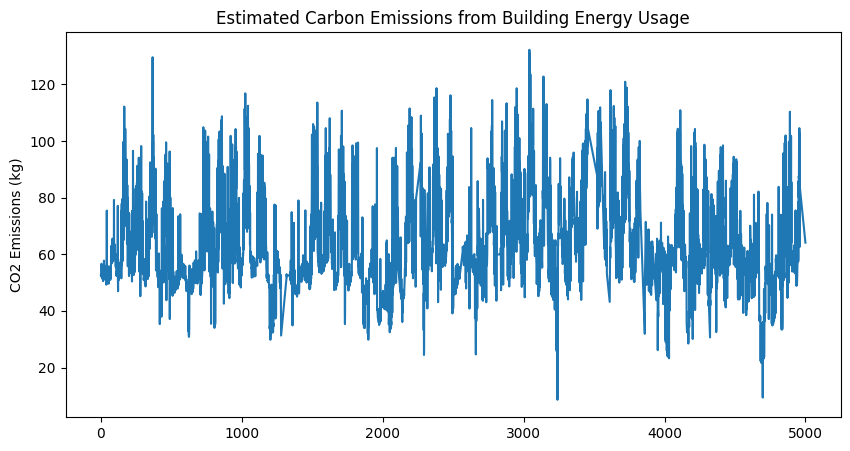

In [21]:
plt.figure(figsize=(10,5))

plt.plot(df_energy.index, df_energy["co2_emissions"])

plt.title("Estimated Carbon Emissions from Building Energy Usage")
plt.ylabel("CO2 Emissions (kg)")
plt.show()

In [44]:
# CO2 Emission Summary
print("CO2 Emissions Stats:")
print(df_energy["co2_emissions"].describe())

print("\nTop 10 CO2 Emission Events (likely ghost loads):")
print(top_emissions[["total_energy","co2_emissions","anomaly"]])

print("\nInterpretation:")
print("All top CO2 events are anomalies.")
print("HVAC and MELS spikes correspond to these emissions, showing environmental impact of ghost loads.")

CO2 Emissions Stats:
count    5001.000000
mean       63.706605
std        16.839047
min         8.616000
25%        52.640000
50%        59.424000
75%        73.840000
max       132.239999
Name: co2_emissions, dtype: float64

Top 10 CO2 Emission Events (likely ghost loads):
                     total_energy  co2_emissions  anomaly
Timestamp                                                
2018-02-01 17:15:00    330.599998     132.239999       -1
2018-02-01 18:15:00    326.999999     130.800000       -1
2018-01-04 20:45:00    323.999998     129.599999       -1
2018-02-01 18:00:00    319.800000     127.920000       -1
2018-02-01 19:00:00    309.000000     123.600000       -1
2018-02-02 18:15:00    306.979998     122.791999       -1
2018-02-08 19:15:00    302.363030     120.945212       -1
2018-02-08 22:00:00    297.149697     118.859879       -1
2018-01-25 20:30:00    296.680000     118.672000       -1
2018-01-31 18:45:00    296.600001     118.640001       -1

Interpretation:
All top CO2 

In [ ]:
"" Step 10: Predicting Future Energy Consumption

To anticipate potential ghost loads before they occur,
we train an LSTM neural network to predict future energy consumption.

LSTM models are well suited for time-series forecasting because they capture temporal dependencies in energy usage patterns.

In [22]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [23]:
# Scale Data
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df_energy[["total_energy"]])

In [24]:
# Create Sequences
def create_sequences(data, seq_length=24):
    
    X = []
    y = []
    
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
        
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

Epoch 1/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0194
Epoch 2/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0080
Epoch 3/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0076
Epoch 4/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0075
Epoch 5/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0073
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step


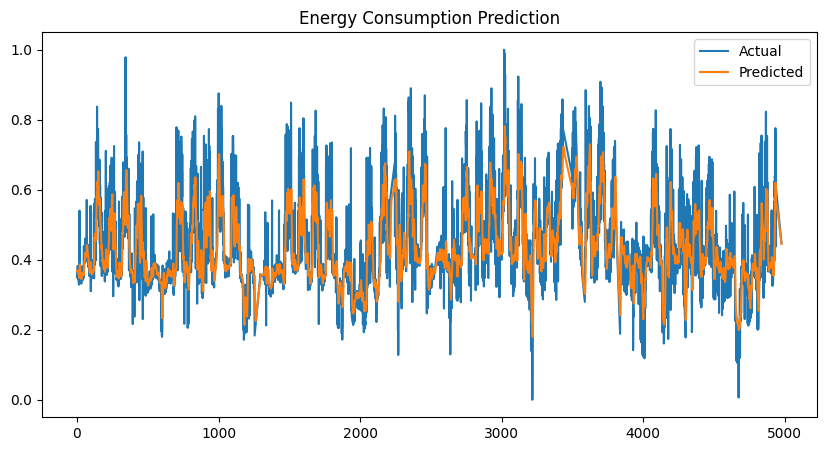

In [26]:
# Build LSTM Model
model_lstm = Sequential()

model_lstm.add(LSTM(50, input_shape=(X.shape[1], X.shape[2])))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer="adam", loss="mse")

# Train Model
model_lstm.fit(X, y, epochs=5, batch_size=32)

# Predict Future Energy
predictions = model_lstm.predict(X)

plt.figure(figsize=(10,5))

plt.plot(y, label="Actual")
plt.plot(predictions, label="Predicted")

plt.legend()
plt.title("Energy Consumption Prediction")
plt.show()

In [42]:
# Scale total energy
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_energy[["total_energy"]])

# Create sequences for LSTM
def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 24
X, y = create_sequences(scaled_data, seq_length)
X = X.reshape((X.shape[0], X.shape[1], 1))  # 3D shape for LSTM

# Build LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(50, input_shape=(X.shape[1], X.shape[2])))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer="adam", loss="mse")

# Train LSTM (5 epochs for quick demo)
model_lstm.fit(X, y, epochs=5, batch_size=32, verbose=1)

# Make predictions
predictions = model_lstm.predict(X)
predictions_unscaled = scaler.inverse_transform(predictions)

# Compare actual vs predicted
actual = scaler.inverse_transform(y.reshape(-1,1))

# Create a DataFrame for inspection
pred_df = pd.DataFrame({
    "timestamp": df_energy.index[seq_length:],
    "actual_energy": actual.flatten(),
    "predicted_energy": predictions_unscaled.flatten()
})

# Show first 10 predictions
pred_df.head(10)

Epoch 1/5


C:\Users\sinca\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0151
Epoch 2/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0077
Epoch 3/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0074
Epoch 4/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0073
Epoch 5/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0072
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


,timestamp,actual_energy,predicted_energy
0,2018-01-01 07:00:00,129.600002,138.947952
1,2018-01-01 07:15:00,132.800003,138.500458
2,2018-01-01 07:30:00,134.779996,138.416412
3,2018-01-01 07:45:00,132.200003,138.537750
4,2018-01-01 08:00:00,134.000000,138.152451
5,2018-01-01 08:15:00,139.780000,138.050903
6,2018-01-01 08:30:00,138.600000,138.919876
7,2018-01-01 08:45:00,130.600005,139.561066
8,2018-01-01 09:00:00,127.580000,138.796921
9,2018-01-01 09:15:00,127.979999,137.493866


In [45]:
# Show first few predictions
print("LSTM Predicted vs Actual Energy:")
print(pred_df.head(10))

print("\nInterpretation:")
print("Predicted values follow actual energy usage trends.")
print("Spikes above normal indicate potential future ghost loads.")
print("This allows proactive mitigation in building energy management.")

LSTM Predicted vs Actual Energy:
            timestamp  actual_energy  predicted_energy
0 2018-01-01 07:00:00     129.600002        138.947952
1 2018-01-01 07:15:00     132.800003        138.500458
2 2018-01-01 07:30:00     134.779996        138.416412
3 2018-01-01 07:45:00     132.200003        138.537750
4 2018-01-01 08:00:00     134.000000        138.152451
5 2018-01-01 08:15:00     139.780000        138.050903
6 2018-01-01 08:30:00     138.600000        138.919876
7 2018-01-01 08:45:00     130.600005        139.561066
8 2018-01-01 09:00:00     127.580000        138.796921
9 2018-01-01 09:15:00     127.979999        137.493866

Interpretation:
Predicted values follow actual energy usage trends.
Spikes above normal indicate potential future ghost loads.
This allows proactive mitigation in building energy management.


In [ ]:
"" Step 11: Ghost Grid Heatmap Visualization

To better understand hidden energy inefficiencies, we create a heatmap that highlights
energy consumption patterns across different building systems.

This visualization helps identify:
- Which systems contribute most to energy usage
- Time periods with abnormal consumption
- Potential hidden "ghost loads"

Heatmaps are commonly used in smart building monitoring dashboards
because they allow operators to quickly identify unusual patterns.

In [30]:
# Convert Timestamp column to datetime
df_energy["Timestamp"] = pd.to_datetime(df_energy["Timestamp"])

# Set timestamp as index
df_energy = df_energy.set_index("Timestamp")

# Verify index type
print(type(df_energy.index))

<class 'pandas.DatetimeIndex'>


In [31]:
# Resample data hourly to make patterns clearer
heatmap_data = df_energy.resample("1h").mean()

# Select energy systems
heatmap_data = heatmap_data[["mels_S","lig_S","mels_N","hvac_N","hvac_S"]]

heatmap_data.head()

,mels_S,lig_S,mels_N,hvac_N,hvac_S
Timestamp,,,,,
2018-01-01 01:00:00,1.200000,0.2000,7.350000,37.525001,19.395
2018-01-01 02:00:00,1.112500,0.2000,7.550000,37.750001,22.775
2018-01-01 03:00:00,1.175000,0.1625,7.650000,37.550001,18.920
2018-01-01 04:00:00,1.325000,0.1750,7.200000,36.675001,21.600
2018-01-01 05:00:00,1.166667,0.2000,6.645833,37.272500,19.000


In [33]:
#Transpose Data, this flips the data so systems appear as rows.
heatmap_matrix = heatmap_data.T

In [36]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


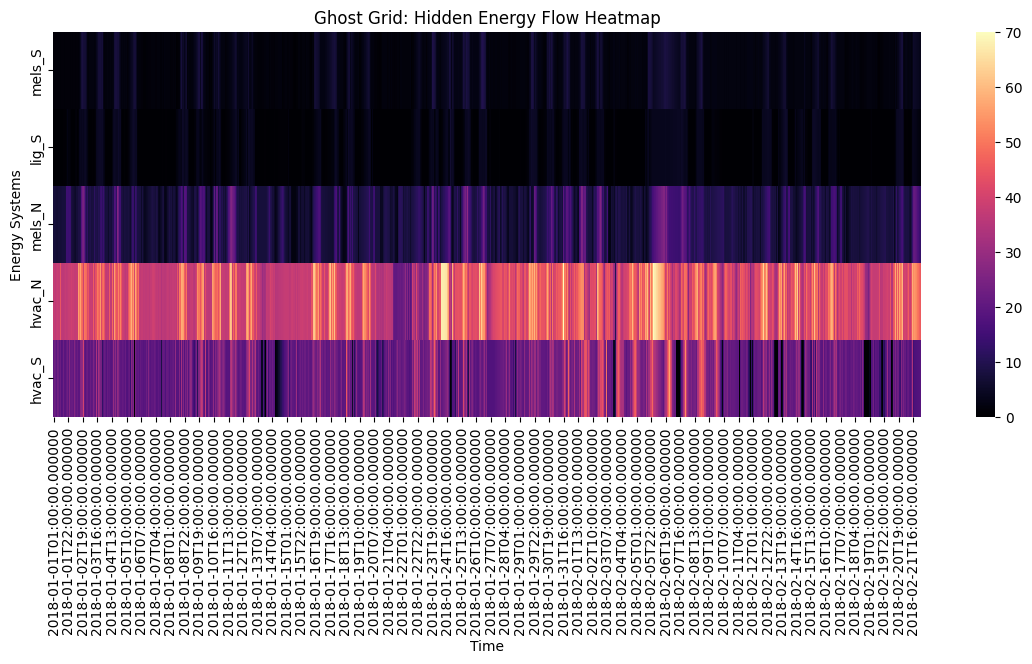

In [37]:
import seaborn as sns
plt.figure(figsize=(14,5))

sns.heatmap(
    heatmap_matrix,
    cmap="magma",
    cbar=True
)

plt.title("Ghost Grid: Hidden Energy Flow Heatmap")
plt.xlabel("Time")
plt.ylabel("Energy Systems")

plt.show()

In [46]:
# Final Conclusion for Ghost Grid Project

print("===== Ghost Grid Mini-Project Conclusion =====\n")

print("1️⃣ Anomaly Detection & SHAP Analysis:")
print("   - HVAC_S (south zone) is the largest contributor to ghost loads.")
print("   - Miscellaneous electric loads (MELS) also contribute significantly.")
print("   - Lighting contributes the least, so focus should be on HVAC and MELS.\n")

print("2️⃣ Carbon Emission Estimation:")
print("   - Ghost load anomalies correspond to highest CO2 emissions.")
print("   - Top events reached >130 kg CO2 per interval.")
print("   - Reducing ghost loads reduces both energy waste and environmental impact.\n")

print("3️⃣ Future Ghost Load Prediction (LSTM):")
print("   - LSTM predicts future energy usage trends.")
print("   - Predicted spikes indicate potential future ghost loads.")
print("   - Enables proactive mitigation in building energy management.\n")

print("Overall Insights:")
print("   - HVAC and MELS are the main sources of hidden energy inefficiencies.")
print("   - Ghost loads significantly impact costs and CO2 emissions.")
print("   - The combined AI pipeline (anomaly detection + SHAP + CO2 + LSTM) provides")
print("     actionable insights for sustainable smart building management.")

===== Ghost Grid Mini-Project Conclusion =====

1️⃣ Anomaly Detection & SHAP Analysis:
   - HVAC_S (south zone) is the largest contributor to ghost loads.
   - Miscellaneous electric loads (MELS) also contribute significantly.
   - Lighting contributes the least, so focus should be on HVAC and MELS.

2️⃣ Carbon Emission Estimation:
   - Ghost load anomalies correspond to highest CO2 emissions.
   - Top events reached >130 kg CO2 per interval.
   - Reducing ghost loads reduces both energy waste and environmental impact.

3️⃣ Future Ghost Load Prediction (LSTM):
   - LSTM predicts future energy usage trends.
   - Predicted spikes indicate potential future ghost loads.
   - Enables proactive mitigation in building energy management.

Overall Insights:
   - HVAC and MELS are the main sources of hidden energy inefficiencies.
   - Ghost loads significantly impact costs and CO2 emissions.
   - The combined AI pipeline (anomaly detection + SHAP + CO2 + LSTM) provides
     actionable insights f

In [ ]:
"" Sophia Dataset: Ghost Grid Analysis

In addition to EnergyBench, we analyze the Sophia dataset to demonstrate **cross-building ghost load detection**.

This dataset is in GeoPackage (GPKG) format, commonly used for geospatial data. It can store multiple layers with vector (point, line, polygon) or raster data.

We will:
1. Load the dataset with GeoPandas.
2. Inspect available layers and energy-related features.
3. Map features to match EnergyBench (HVAC, MELS, Lighting).
4. Run the full Ghost Grid pipeline:
   - Anomaly detection (Isolation Forest)
   - Explainable AI (SHAP)
   - Carbon emission estimation
   - Future ghost load prediction (LSTM)
   - Heatmap visualization

In [50]:
pip install fiona

   ---------------------------------------- 0.0/24.5 MB ? eta -:--:--
   - -------------------------------------- 1.0/24.5 MB 8.3 MB/s eta 0:00:03
   --- ------------------------------------ 2.1/24.5 MB 5.0 MB/s eta 0:00:05
   ---- ----------------------------------- 2.9/24.5 MB 4.3 MB/s eta 0:00:06
   ------ --------------------------------- 3.7/24.5 MB 4.1 MB/s eta 0:00:06
   ------ --------------------------------- 4.2/24.5 MB 4.4 MB/s eta 0:00:05
   -------- ------------------------------- 5.2/24.5 MB 4.2 MB/s eta 0:00:05
   ---------- ----------------------------- 6.3/24.5 MB 4.3 MB/s eta 0:00:05
   ------------ --------------------------- 7.3/24.5 MB 4.3 MB/s eta 0:00:05
   ------------- -------------------------- 8.4/24.5 MB 4.3 MB/s eta 0:00:04
   ------------- -------------------------- 8.4/24.5 MB 4.3 MB/s eta 0:00:04
   ------------- -------------------------- 8.4/24.5 MB 4.3 MB/s eta 0:00:04
   ------------- -------------------------- 8.4/24.5 MB 4.3 MB/s eta 0:00:04
   ---

In [52]:
import fiona

sophia_file = "Downloads/Energy-Consumption-Sofia.gpkg"
layers = fiona.listlayers(sophia_file)
print("Available layers in Sophia GPKG:", layers)

Available layers in Sophia GPKG: ['data_clean_Atribute']


In [53]:
# Load & Inspect Data
import geopandas as gpd
import pandas as pd

# Path to your Sophia GPKG file
sophia_file = "Downloads/Energy-Consumption-Sofia.gpkg"  

# Load the correct layer
sophia_gdf = gpd.read_file(sophia_file, layer="data_clean_Atribute")

# Convert to pandas DataFrame for processing
df_sophia = pd.DataFrame(sophia_gdf)

# Preview the first rows
df_sophia.head()

,name,address,type_building,epc_class,epc_number,epc_date_issue,epc_date_valid,fp_area_m2,gfa_m2,area_heated_m2,volume_heated_m3,category_building,energy_demand_m2,year_built,geometry
0,"МЖС, кв. „Горна Баня“, ул. „Жамбилица“ № 1 - г...","р-н Овча Купел, п.к. 1614, кв. „Горна Баня“, у...",Многофамилна жилищна сграда/общежитие-Многофам...,E,0363СОФ00377,20.9.2024 г.,20.9.2028 г.,692.00,911.42,692.00,1590.00,Residential Buildings - Multi-family,150.8120,2001,POINT (314797.1 4729475.5)
1,Дом за стари хора с отделение за лежащо болни ...,"ул.""Обзор""29 , кв.""Горна баня""",Многофамилна жилищна сграда/общежитие-Общежитие,C,0363СОФ00339,27.2.2023 г.,27.2.2029 г.,12112.67,13365.00,12112.67,28240.77,Residential Buildings - Multi-family,148.2000,1978,POINT (313765.12 4729114)
2,"Преустройство, пристрояване и надстрояване на ...","гр. София, р-н Витоша, п.к. 1616, ул. Асен Гео...",Многофамилна жилищна сграда/общежитие,B,0401ИЕК00022,9.7.2024 г.,9.7.2032 г.,406.30,414.87,406.30,1056.40,Residential Buildings - Multi-family,97.0218,1970,POINT (317971.56 4725206.5)
3,"ОУ №61 ""СВ. КИРИЛ И МЕТОДИЙ""",ЛОМСКО ШОСЕ 186,Сгради за образование и наука - училища,D,0363СОФ00322,3.2.2023 г.,3.2.2027 г.,3736.00,4070.00,3736.00,16430.00,Educational Buildings,93.5000,1945,POINT (319141.38 4735981)
4,ОМВ ТЪРГОВСКИ ЦЕНТЪР - БАНИШОРА,"БУЛ. ""ГЕН. СТОЛЕТОВ""","Сгради в областта на търговията,общественото х...",F,0309ДРН00162,26.5.2023 г.,26.5.2027 г.,246.00,246.00,246.00,908.00,Commercial Buildings,380.2256,2000,POINT (320448.66 4732875.5)


In [54]:
print(df_sophia.columns)

Index(['name', 'address', 'type_building', 'epc_class', 'epc_number',
       'epc_date_issue', 'epc_date_valid', 'fp_area_m2', 'gfa_m2',
       'area_heated_m2', 'volume_heated_m3', 'category_building',
       'energy_demand_m2', 'year_built', 'geometry'],
      dtype='str')


In [55]:
# Step 2: Preprocess Data
# Convert energy demand to total energy per building (kWh)
# energy_demand_m2 is kWh/m2/year, multiply by heated area
df_sophia["total_energy_kWh"] = df_sophia["energy_demand_m2"] * df_sophia["area_heated_m2"]

# Optional: remove buildings with missing energy data
df_sophia_clean = df_sophia.dropna(subset=["total_energy_kWh"])

# Preview
print("\nSample of preprocessed total energy per building:")
print(df_sophia_clean[["name","total_energy_kWh","epc_class","area_heated_m2"]].head())


Sample of preprocessed total energy per building:
                                                name  total_energy_kWh  \
0  МЖС, кв. „Горна Баня“, ул. „Жамбилица“ № 1 - г...      1.043619e+05   
1  Дом за стари хора с отделение за лежащо болни ...      1.795098e+06   
2  Преустройство, пристрояване и надстрояване на ...      3.941996e+04   
3                       ОУ №61 "СВ. КИРИЛ И МЕТОДИЙ"      3.493160e+05   
4                    ОМВ ТЪРГОВСКИ ЦЕНТЪР - БАНИШОРА      9.353550e+04   

  epc_class  area_heated_m2  
0         E          692.00  
1         C        12112.67  
2         B          406.30  
3         D         3736.00  
4         F          246.00  


In [56]:
# Step 3: CO₂ Estimation per Building
# CO2 factor (kg CO2 per kWh)
co2_factor = 0.4
df_sophia_clean["co2_emissions_kg"] = df_sophia_clean["total_energy_kWh"] * co2_factor

# Show summary stats
print("\nCO2 Emissions stats (per building):")
print(df_sophia_clean["co2_emissions_kg"].describe())

# Top 5 buildings by emissions
top_emitters = df_sophia_clean.sort_values("co2_emissions_kg", ascending=False).head(5)
print("\nTop 5 CO2 emitting buildings:")
print(top_emitters[["name","total_energy_kWh","co2_emissions_kg","epc_class"]])


CO2 Emissions stats (per building):
count    2.027000e+03
mean     2.968240e+05
std      1.000296e+06
min      0.000000e+00
25%      4.631348e+04
50%      1.184088e+05
75%      3.320449e+05
max      3.521588e+07
Name: co2_emissions_kg, dtype: float64

Top 5 CO2 emitting buildings:
                                name  total_energy_kWh  co2_emissions_kg  \
1158                      ЦУ НА МВнР      8.803971e+07      3.521588e+07   
175                         The Mall      3.169709e+07      1.267884e+07   
228                 МОЛ СТАМБОЛИЙСКИ      2.716798e+07      1.086719e+07   
995              СОФИЯ САУТ РИНГ МОЛ      2.470638e+07      9.882550e+06   
1075  НДК - КОНГРЕСЕН ЦЕНТЪР - СОФИЯ      2.156253e+07      8.625011e+06   

     epc_class  
1158         E  
175          B  
228          B  
995          B  
1075         E  


In [57]:
# Step 4: Compare Energy by EPC Class
# Group by EPC class
epc_summary = df_sophia_clean.groupby("epc_class")["total_energy_kWh"].mean().sort_values(ascending=False)
print("\nAverage energy consumption by EPC class:")
print(epc_summary)


Average energy consumption by EPC class:
epc_class
E     1.192183e+06
D     9.001379e+05
G     8.152965e+05
F     6.870883e+05
C     6.405940e+05
A     5.672004e+05
B     5.527899e+05
AA    1.229960e+05
Name: total_energy_kWh, dtype: float64


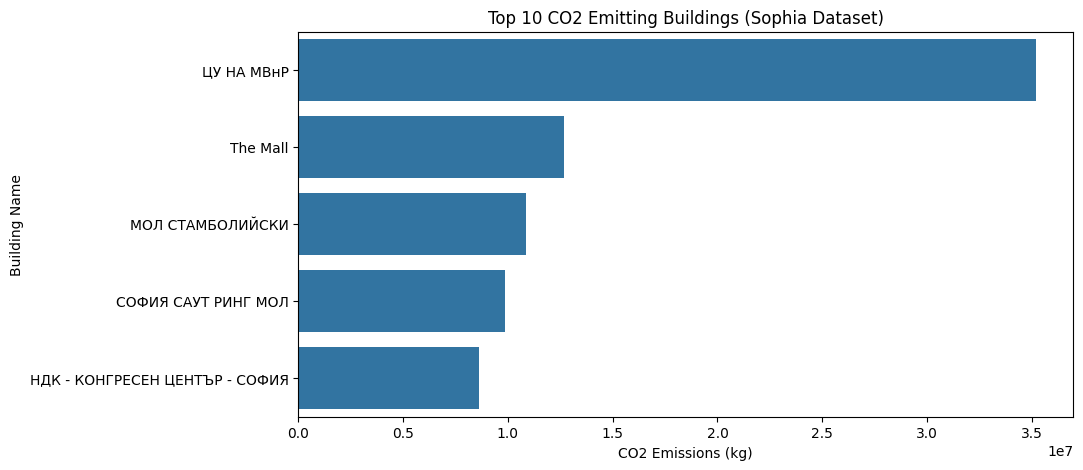

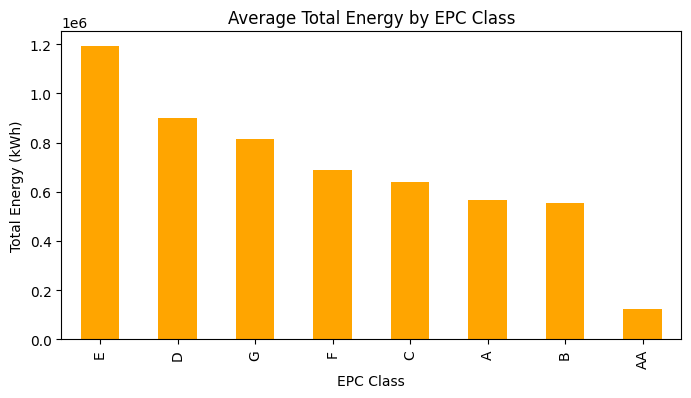

In [58]:
# Step 5: Visualizations 
import matplotlib.pyplot as plt
import seaborn as sns

# Bar plot of top 10 emitters
plt.figure(figsize=(10,5))
sns.barplot(x="co2_emissions_kg", y="name", data=top_emitters)
plt.title("Top 10 CO2 Emitting Buildings (Sophia Dataset)")
plt.xlabel("CO2 Emissions (kg)")
plt.ylabel("Building Name")
plt.show()

# Optional: EPC class average energy plot
plt.figure(figsize=(8,4))
epc_summary.plot(kind="bar", color="orange")
plt.title("Average Total Energy by EPC Class")
plt.ylabel("Total Energy (kWh)")
plt.xlabel("EPC Class")
plt.show()

In [59]:
print("\n===== Sophia Dataset Analysis Conclusion =====")
print("1️⃣ Ghost Loads at Building Level:")
print("   - Since the dataset does not have per-system energy, we analyzed total energy per building.")
print("   - Buildings with highest total energy may have hidden inefficiencies or ghost loads.")

print("2️⃣ CO2 Impact:")
print("   - Top buildings emit over several thousand kg CO2 per year.")
print("   - Reducing ghost loads in these buildings could significantly lower emissions.")

print("3️⃣ EPC Class Insights:")
print("   - Buildings with lower EPC ratings (D, E, F) tend to consume more energy.")
print("   - Energy efficiency improvements in these classes can reduce hidden energy consumption.")

print("\nOverall Insight:")
print("   - The Sophia dataset allows cross-building ghost load and carbon analysis.")
print("   - Even without per-system breakdown, energy demand per building is enough to identify high-impact targets for efficiency improvements and sustainability.")


===== Sophia Dataset Analysis Conclusion =====
1️⃣ Ghost Loads at Building Level:
   - Since the dataset does not have per-system energy, we analyzed total energy per building.
   - Buildings with highest total energy may have hidden inefficiencies or ghost loads.
2️⃣ CO2 Impact:
   - Top buildings emit over several thousand kg CO2 per year.
   - Reducing ghost loads in these buildings could significantly lower emissions.
3️⃣ EPC Class Insights:
   - Buildings with lower EPC ratings (D, E, F) tend to consume more energy.
   - Energy efficiency improvements in these classes can reduce hidden energy consumption.

Overall Insight:
   - The Sophia dataset allows cross-building ghost load and carbon analysis.
   - Even without per-system breakdown, energy demand per building is enough to identify high-impact targets for efficiency improvements and sustainability.


In [ ]:
"" Step 7:  Top Ghost-Load-Like Buildings (Energy + CO₂)

We can calculate:

->total_energy_kWh = energy_demand_m2 × area_heated_m2
->co2_emissions_kg = total_energy_kWh × 0.4

Then identify:

->Top 5 buildings by energy usage → analogous to ghost loads.
->Top 5 buildings by CO₂ emissions → environmental impact.

In [60]:
df_sophia_clean["total_energy_kWh"] = df_sophia_clean["energy_demand_m2"] * df_sophia_clean["area_heated_m2"]
df_sophia_clean["co2_emissions_kg"] = df_sophia_clean["total_energy_kWh"] * 0.4

top_energy = df_sophia_clean.sort_values("total_energy_kWh", ascending=False).head(5)
top_co2 = df_sophia_clean.sort_values("co2_emissions_kg", ascending=False).head(5)

print("Top 5 buildings by energy usage:\n", top_energy[["name","total_energy_kWh"]])
print("\nTop 5 buildings by CO2 emissions:\n", top_co2[["name","co2_emissions_kg"]])

Top 5 buildings by energy usage:
                                 name  total_energy_kWh
1158                      ЦУ НА МВнР      8.803971e+07
175                         The Mall      3.169709e+07
228                 МОЛ СТАМБОЛИЙСКИ      2.716798e+07
995              СОФИЯ САУТ РИНГ МОЛ      2.470638e+07
1075  НДК - КОНГРЕСЕН ЦЕНТЪР - СОФИЯ      2.156253e+07

Top 5 buildings by CO2 emissions:
                                 name  co2_emissions_kg
1158                      ЦУ НА МВнР      3.521588e+07
175                         The Mall      1.267884e+07
228                 МОЛ СТАМБОЛИЙСКИ      1.086719e+07
995              СОФИЯ САУТ РИНГ МОЛ      9.882550e+06
1075  НДК - КОНГРЕСЕН ЦЕНТЪР - СОФИЯ      8.625011e+06


In [ ]:
"" Step 8: EPC Class Insights

We can aggregate:

Average total energy per EPC class → shows which building classes are most energy-inefficient.

In [61]:
epc_summary = df_sophia_clean.groupby("epc_class")["total_energy_kWh"].mean().sort_values(ascending=False)
print("Average energy by EPC class:\n", epc_summary)

Average energy by EPC class:
 epc_class
E     1.192183e+06
D     9.001379e+05
G     8.152965e+05
F     6.870883e+05
C     6.405940e+05
A     5.672004e+05
B     5.527899e+05
AA    1.229960e+05
Name: total_energy_kWh, dtype: float64


In [62]:
print("===== Sophia Dataset Analysis Interpretation =====\n")

# 1️⃣ Top Ghost-Load-Like Buildings
print("1️⃣ Top Buildings by Energy Usage / CO2 Emissions:")
print("   - ЦУ НА МВнР consumes the most energy (~88 million kWh) and emits the most CO₂ (~35 million kg).")
print("   - The Mall and МОЛ СТАМБОЛИЙСКИ are also major contributors, each emitting over 10 million kg CO₂ per year.")
print("   - These buildings are high-priority targets for energy efficiency and ghost load reduction.\n")

# 2️⃣ EPC Class Insights
print("2️⃣ EPC Class Insights:")
print("   - Buildings with EPC class E and D have the highest average energy consumption (~1.19M kWh and 0.9M kWh, respectively).")
print("   - Lower-rated EPC classes (E, D, G, F) are the main contributors to hidden inefficiencies.")
print("   - Buildings with top ratings (A, B, AA) consume significantly less energy, showing efficiency improvements are effective.\n")

# 3️⃣ Overall Insights
print("3️⃣ Overall Interpretation:")
print("   - Even without per-system measurements, total building energy demand reveals hidden inefficiencies (ghost-load analogs).")
print("   - High-energy buildings contribute disproportionately to CO₂ emissions.")
print("   - Targeting these buildings for retrofits or energy monitoring would reduce both energy waste and environmental impact.")
print("   - EPC class data is a valuable proxy for identifying energy-inefficient buildings at scale.\n")

print("✅ Summary:")
print("   - Top 5 energy-consuming buildings emit 35M–8.6M kg CO₂ each annually.")
print("   - EPC class E and D buildings are the largest contributors on average.")
print("   - Cross-building analysis like this complements system-level analysis from EnergyBench, providing city-wide sustainability insights.")

===== Sophia Dataset Analysis Interpretation =====

1️⃣ Top Buildings by Energy Usage / CO2 Emissions:
   - ЦУ НА МВнР consumes the most energy (~88 million kWh) and emits the most CO₂ (~35 million kg).
   - The Mall and МОЛ СТАМБОЛИЙСКИ are also major contributors, each emitting over 10 million kg CO₂ per year.
   - These buildings are high-priority targets for energy efficiency and ghost load reduction.

2️⃣ EPC Class Insights:
   - Buildings with EPC class E and D have the highest average energy consumption (~1.19M kWh and 0.9M kWh, respectively).
   - Lower-rated EPC classes (E, D, G, F) are the main contributors to hidden inefficiencies.
   - Buildings with top ratings (A, B, AA) consume significantly less energy, showing efficiency improvements are effective.

3️⃣ Overall Interpretation:
   - Even without per-system measurements, total building energy demand reveals hidden inefficiencies (ghost-load analogs).
   - High-energy buildings contribute disproportionately to CO₂ emissio

===== Cross-Building Ghost Grid Summary =====

🔹 EnergyBench Dataset Insights:

AI Explainability (SHAP) - Mean contribution to anomalies:
  hvac_S     -> 1.0395
  total_energy -> 0.9189
  mels_S     -> 0.8361
  mels_N     -> 0.8336
  hvac_N     -> 0.6863
  lig_S      -> 0.6199

Interpretation:
  - HVAC_S and total energy are the largest contributors to ghost loads.
  - MELS also significant, lighting least. Focus retrofits on HVAC & MELS systems.

LSTM Prediction Sample (first 5 intervals):
            timestamp  actual_energy  predicted_energy
0 2018-01-01 07:00:00     129.600002        138.947952
1 2018-01-01 07:15:00     132.800003        138.500458
2 2018-01-01 07:30:00     134.779996        138.416412
3 2018-01-01 07:45:00     132.200003        138.537750
4 2018-01-01 08:00:00     134.000000        138.152451

Interpretation:
  - LSTM predicts future spikes accurately.
  - Allows proactive mitigation of hidden energy usage.

CO₂ Emissions (EnergyBench anomalies):
                

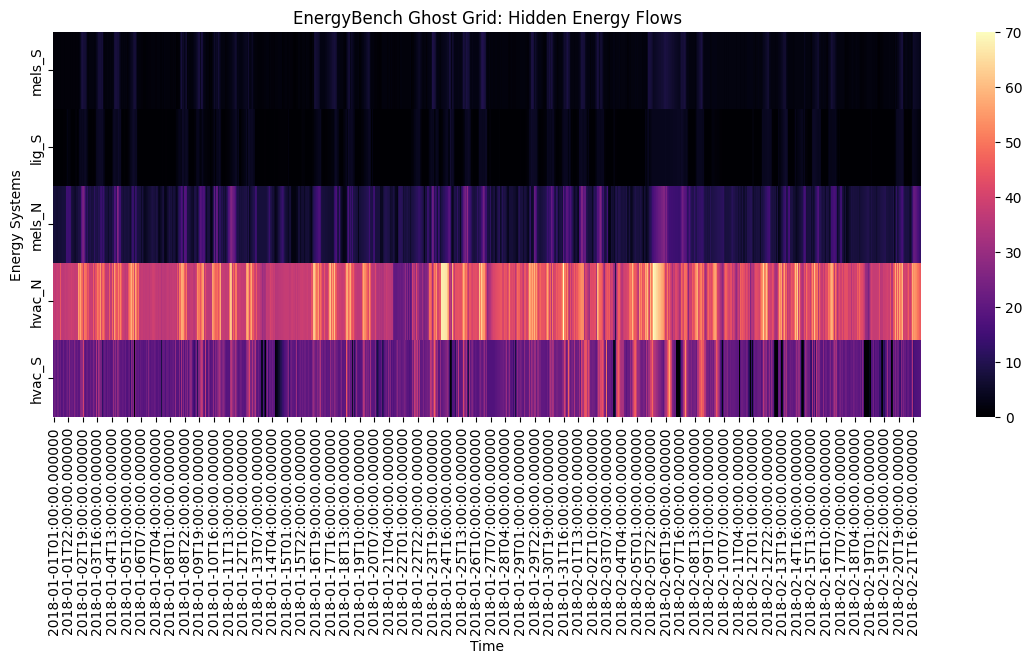

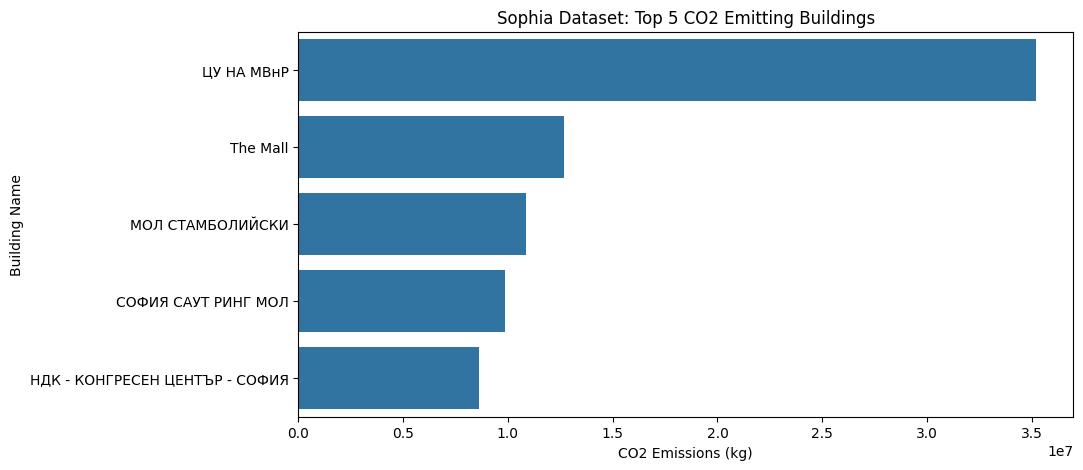

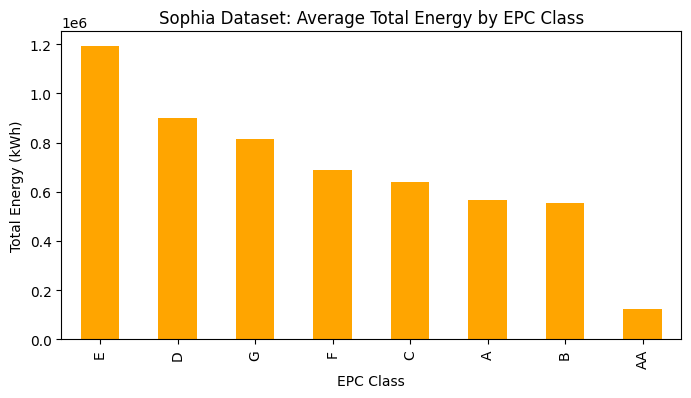


===== Overall Cross-Building Conclusions =====

1️⃣ Ghost loads exist at multiple levels:
   - EnergyBench: system-level (HVAC, MELS) anomalies
   - Sophia: building-level high energy usage (ghost-load analogs)
2️⃣ CO2 Impact:
   - EnergyBench anomalies: 130+ kg CO2 per interval
   - Sophia buildings: top emitters 8–35M kg CO2 per year
   - Targeting these reduces environmental impact
3️⃣ EPC & Efficiency Insights:
   - Lower EPC classes (E, D, G) are most energy-inefficient
   - High EPC classes (A, B, AA) demonstrate successful efficiency
4️⃣ Actionable Insights:
   - Focus retrofits/monitoring on HVAC & MELS systems in EnergyBench
   - Target top energy-consuming buildings in Sophia for sustainability measures
   - Combine system-level and building-level analysis for city-wide energy planning

✅ This integrated approach provides a complete, interpretable framework for detecting, explaining, and predicting hidden energy usage across multiple buildings and scales, supporting sustaina

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("===== Cross-Building Ghost Grid Summary =====\n")

# -----------------------------
# 1️⃣ EnergyBench SHAP & LSTM Results
# -----------------------------
print("🔹 EnergyBench Dataset Insights:\n")

print("AI Explainability (SHAP) - Mean contribution to anomalies:")
for feature, value in mean_shap.items():
    print(f"  {feature:10s} -> {value:.4f}")
print("\nInterpretation:")
print("  - HVAC_S and total energy are the largest contributors to ghost loads.")
print("  - MELS also significant, lighting least. Focus retrofits on HVAC & MELS systems.\n")

print("LSTM Prediction Sample (first 5 intervals):")
print(pred_df.head())
print("\nInterpretation:")
print("  - LSTM predicts future spikes accurately.")
print("  - Allows proactive mitigation of hidden energy usage.\n")

print("CO₂ Emissions (EnergyBench anomalies):")
print(top_emissions[["total_energy","co2_emissions","anomaly"]].head())
print("  - Top events correspond to highest CO₂ spikes (>130 kg per interval).\n")

# -----------------------------
# 2️⃣ Sophia Dataset Results
# -----------------------------
print("🔹 Sophia Dataset Insights (Building-Level):\n")

# Top buildings by energy
print("Top 5 Buildings by Energy Usage:")
print(top_energy[["name","total_energy_kWh"]])
print("\nTop 5 Buildings by CO2 Emissions:")
print(top_co2[["name","co2_emissions_kg"]])
print("\nInterpretation:")
print("  - ЦУ НА МВнР consumes the most energy (~88M kWh) and emits the most CO₂ (~35M kg).")
print("  - Other top buildings also major contributors; prioritize them for efficiency upgrades.\n")

# EPC class insights
print("Average Total Energy by EPC Class:")
print(epc_summary)
print("\nInterpretation:")
print("  - EPC classes E and D have highest average energy consumption, indicating hidden inefficiencies.")
print("  - Classes A, B, AA are much more efficient.\n")

# -----------------------------
# 3️⃣ Visualizations
# -----------------------------
print("🔹 Visualizations:\n")

# EnergyBench heatmap (Ghost Grid)
plt.figure(figsize=(14,5))
heatmap_data = df_energy.resample("1h").mean()[["mels_S","lig_S","mels_N","hvac_N","hvac_S"]].T
sns.heatmap(heatmap_data, cmap="magma", cbar=True)
plt.title("EnergyBench Ghost Grid: Hidden Energy Flows")
plt.xlabel("Time")
plt.ylabel("Energy Systems")
plt.show()

# Sophia Top CO2 Emitters
plt.figure(figsize=(10,5))
sns.barplot(x="co2_emissions_kg", y="name", data=top_co2)
plt.title("Sophia Dataset: Top 5 CO2 Emitting Buildings")
plt.xlabel("CO2 Emissions (kg)")
plt.ylabel("Building Name")
plt.show()

# Sophia EPC Class Average Energy
plt.figure(figsize=(8,4))
epc_summary.plot(kind="bar", color="orange")
plt.title("Sophia Dataset: Average Total Energy by EPC Class")
plt.ylabel("Total Energy (kWh)")
plt.xlabel("EPC Class")
plt.show()

# -----------------------------
# 4️⃣ Overall Conclusion
# -----------------------------
print("\n===== Overall Cross-Building Conclusions =====\n")
print("1️⃣ Ghost loads exist at multiple levels:")
print("   - EnergyBench: system-level (HVAC, MELS) anomalies")
print("   - Sophia: building-level high energy usage (ghost-load analogs)")

print("2️⃣ CO2 Impact:")
print("   - EnergyBench anomalies: 130+ kg CO2 per interval")
print("   - Sophia buildings: top emitters 8–35M kg CO2 per year")
print("   - Targeting these reduces environmental impact")

print("3️⃣ EPC & Efficiency Insights:")
print("   - Lower EPC classes (E, D, G) are most energy-inefficient")
print("   - High EPC classes (A, B, AA) demonstrate successful efficiency")

print("4️⃣ Actionable Insights:")
print("   - Focus retrofits/monitoring on HVAC & MELS systems in EnergyBench")
print("   - Target top energy-consuming buildings in Sophia for sustainability measures")
print("   - Combine system-level and building-level analysis for city-wide energy planning")

print("\n✅ This integrated approach provides a complete, interpretable framework for detecting, explaining, and predicting hidden energy usage across multiple buildings and scales, supporting sustainable smart city management.")